#  Previsão de Vendas com Base em Dados Históricos

Este projeto aplica técnicas de Análise Exploratória de Dados (EDA) e Aprendizado de Máquina ao problema de previsão de vendas em um cenário de e-commerce, com o objetivo de identificar padrões de comportamento ao longo do tempo e desenvolver modelos capazes de estimar vendas futuras com base em dados históricos.

A análise busca compreender os principais fatores que influenciam o volume de vendas, incluindo sazonalidade, promoções, feriados e investimentos em marketing. Além disso, investiga-se a relação entre essas variáveis e o desempenho comercial, bem como a capacidade de modelos preditivos em capturar essas dinâmicas e apoiar decisões estratégicas.

---

##  Descrição do Conjunto de Dados

O conjunto de dados contém informações mensais de vendas de um e-commerce, onde cada observação representa um período específico.

As variáveis incluem:

- **Data** — referência temporal das observações  
- **Vendas** — volume total de vendas no período  
- **Promoção** — indicador de campanhas promocionais  
- **Investimento em Marketing** — valor investido em ações de marketing  
- **Feriado** — indicador de períodos com feriados  
- **Preço Médio** — valor médio dos produtos vendidos  

O dataset apresenta uma estrutura temporal, sendo ideal para análise de tendências, sazonalidade e modelagem preditiva baseada em séries históricas.

---

##  Objetivos

O projeto tem como principais objetivos:

- Realizar uma Análise Exploratória de Dados (EDA) para entender o comportamento das vendas ao longo do tempo  
- Identificar padrões sazonais e tendências de crescimento  
- Avaliar o impacto de promoções, feriados e marketing nas vendas  
- Investigar a relação entre preço médio e volume de vendas  
- Desenvolver modelos preditivos para estimar vendas futuras  
- Avaliar o desempenho dos modelos utilizando métricas adequadas  
- Interpretar os resultados com foco em tomada de decisão  
- Gerar insights estratégicos para otimização de vendas  

---

##  Metodologia

###  Pré-processamento

- Leitura e inspeção inicial dos dados  
- Conversão da variável de data para formato datetime  
- Tratamento de valores ausentes por imputação de mediana  
- Criação de variáveis temporais (ano, mês, trimestre)  
- Preparação dos dados para análise e modelagem  

---

###  Análise Exploratória de Dados (EDA)

- Análise descritiva das variáveis principais  
- Avaliação da evolução temporal das vendas  
- Identificação de sazonalidade mensal  
- Comparação entre períodos com e sem promoção  
- Análise do impacto de feriados no volume de vendas  
- Investigação da relação entre investimento em marketing e vendas  
- Análise de correlação entre variáveis (heatmap)  
- Identificação de picos e quedas de vendas  

---

##  Modelagem Preditiva

O problema foi tratado como uma tarefa de regressão.

### Modelo utilizado:

- Regressão Linear  

### Procedimentos:

- Definição das variáveis preditoras e variável alvo  
- Divisão dos dados em treino e teste  
- Treinamento do modelo  
- Geração de previsões para dados não vistos  

---

##  Avaliação de Desempenho

As métricas utilizadas para avaliação do modelo foram:

- Erro Absoluto Médio (MAE)  
- Erro Quadrático Médio (MSE)  
- Raiz do Erro Quadrático Médio (RMSE)  
- Coeficiente de Determinação (R²)  

A avaliação considerou a capacidade do modelo em capturar a tendência geral das vendas e sua precisão na estimativa de valores futuros.

---

##  Principais Resultados

- Identificação de crescimento consistente das vendas ao longo do tempo  
- Evidência clara de sazonalidade, com picos em períodos específicos do ano  
- Promoções mostraram impacto significativo no aumento das vendas  
- Feriados concentraram maiores volumes de demanda  
- Forte relação entre investimento em marketing e volume de vendas  
- O modelo de regressão linear capturou a tendência geral, mas apresentou limitações em períodos de alta variabilidade  

---

##  Insights de Negócio

A análise revela que:

- Campanhas promocionais são uma alavanca importante para aumento de vendas  
- Investimentos em marketing estão diretamente associados ao desempenho comercial  
- Períodos sazonais (como fim de ano) exigem planejamento antecipado  
- Feriados representam oportunidades estratégicas para maximização de receita  
- Estratégias de precificação podem influenciar a demanda e devem ser analisadas com maior profundidade  
- Modelos preditivos podem apoiar decisões de estoque, marketing e planejamento financeiro  

---

##  Conclusão

Este projeto demonstra como técnicas de Análise Exploratória de Dados e Modelagem Preditiva podem ser aplicadas na previsão de vendas em e-commerce.

A abordagem adotada evidencia a importância da análise de padrões temporais, da compreensão das variáveis de negócio e da utilização de modelos preditivos como ferramenta de suporte à tomada de decisão. Embora o modelo inicial apresente bons resultados, há oportunidades de melhoria com o uso de modelos mais robustos e técnicas avançadas de engenharia de atributos.

## importação de bibliotecas

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

## Carregamento de Dados

In [ ]:
# Carregamento de Dados

df = pd.read_csv("dataset_vendas_ecommerce.csv")

# Converter coluna de data
df["data"] = pd.to_datetime(df["data"])

# Criar cópia para tratamento
dados = df.copy()

# Tratamento de valores ausentes (imputação por mediana)
for coluna in ["promocao", "investimento_marketing", "preco_medio"]:
    dados[coluna] = dados[coluna].fillna(dados[coluna].median())

# Criar colunas temporais
dados["ano"] = dados["data"].dt.year
dados["mes"] = dados["data"].dt.month
dados["trimestre"] = dados["data"].dt.quarter
dados["nome_mes"] = dados["data"].dt.strftime("%b")

display(df.head())

,data,vendas,promocao,investimento_marketing,feriado,preco_medio
0,2021-01-01,1700.0,0.0,NaN,0.0,111.44
1,2021-02-01,1731.0,0.0,138.01,0.0,113.59
2,2021-03-01,2091.0,0.0,150.28,0.0,118.96
3,2021-04-01,2535.0,0.0,206.60,0.0,113.15
4,2021-05-01,3001.0,1.0,304.83,0.0,103.62


In [ ]:
print("VISÃO GERAL DO DATASET \n")
print(f"Linhas: {dados.shape[0]}")
print(f"Colunas: {dados.shape[1]}")

print("\nTipos de dados:")
print(dados.dtypes)

print("\nValores ausentes (dataset original):")
print(df.isna().sum())

print("\nPeríodo:")
print(f"Início: {dados['data'].min().date()}")
print(f"Fim   : {dados['data'].max().date()}")

VISÃO GERAL DO DATASET 

Linhas: 60
Colunas: 10

Tipos de dados:
data                      datetime64[ns]
vendas                           float64
promocao                         float64
investimento_marketing           float64
feriado                          float64
preco_medio                      float64
ano                                int32
mes                                int32
trimestre                          int32
nome_mes                          object
dtype: object

Valores ausentes (dataset original):
data                      0
vendas                    0
promocao                  1
investimento_marketing    3
feriado                   0
preco_medio               2
dtype: int64

Período:
Início: 2021-01-01
Fim   : 2025-12-01


## Análise Exploratória de dados (EDA)

In [ ]:
# Métricas descritivas
print(dados[["vendas", "promocao", "investimento_marketing", "feriado", "preco_medio"]].describe())

# Resumo anual
resumo_anual = dados.groupby("ano").agg(
    vendas_total=("vendas", "sum"),
    vendas_media=("vendas", "mean"),
    marketing_total=("investimento_marketing", "sum"),
    taxa_promocao=("promocao", "mean"),
    meses_com_feriado=("feriado", "sum"),
    preco_medio=("preco_medio", "mean")
)

# Crescimento anual
resumo_anual["crescimento_%"] = resumo_anual["vendas_total"].pct_change() * 100

print("\nRESUMO ANUAL")
print(resumo_anual)

# Sazonalidade
sazonalidade = dados.groupby("mes").agg(
    vendas_media=("vendas", "mean"),
    marketing_medio=("investimento_marketing", "mean"),
    preco_medio=("preco_medio", "mean")
).sort_values("vendas_media", ascending=False)

print("\nSAZONALIDADE")
print(sazonalidade)

# Impacto promoção
impacto_promocao = dados.groupby("promocao")["vendas"].agg(["mean", "median", "count"])
print("\nIMPACTO PROMOÇÃO")
print(impacto_promocao)

# Impacto feriado
impacto_feriado = dados.groupby("feriado")["vendas"].agg(["mean", "median", "count"])
print("\nIMPACTO FERIADO")
print(impacto_feriado)

# Correlação
correlacoes = dados[["vendas", "promocao", "investimento_marketing", "feriado", "preco_medio"]].corr()
print("\nCORRELAÇÕES")
print(correlacoes)

            vendas   promocao  investimento_marketing    feriado  preco_medio
count    60.000000  60.000000               60.000000  60.000000    60.000000
mean   3537.166333   0.316667              312.297500   0.166667   113.628667
std    1297.990879   0.469102              108.110936   0.375823     6.633338
min    1700.000000   0.000000              138.010000   0.000000    96.360000
25%    2714.545000   0.000000              246.797500   0.000000   110.420000
50%    3327.000000   0.000000              304.830000   0.000000   113.620000
75%    3999.000000   1.000000              375.332500   0.000000   117.817500
max    8802.800000   1.000000              689.310000   1.000000   127.890000

RESUMO ANUAL
      vendas_total  vendas_media  marketing_total  taxa_promocao  \
ano                                                                
2021      31182.00   2598.500000          2976.29       0.333333   
2022      38077.00   3173.083333          3292.19       0.333333   
2023      40

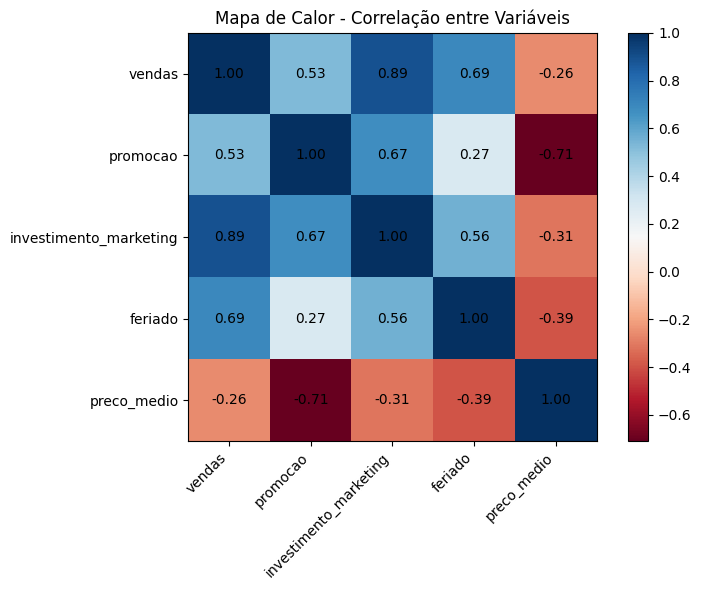

In [ ]:
# HEATMAP
correlacoes = dados[["vendas", "promocao", "investimento_marketing", "feriado", "preco_medio"]].corr()
plt.figure(figsize=(8, 6))
plt.imshow(correlacoes, interpolation='nearest', cmap='RdBu')
plt.colorbar()

# Labels dos eixos
labels = correlacoes.columns
plt.xticks(ticks=np.arange(len(labels)), labels=labels, rotation=45, ha='right')
plt.yticks(ticks=np.arange(len(labels)), labels=labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        valor = correlacoes.iloc[i, j]
        plt.text(j, i, f"{valor:.2f}", ha='center', va='center')

plt.title("Mapa de Calor - Correlação entre Variáveis")
plt.tight_layout()
plt.show()

### Análise de Correlação (Mapa de Calor)

Este mapa de calor visualiza a correlação entre as diferentes variáveis. Valores próximos a 1 (vermelho forte) indicam uma correlação positiva forte, ou seja, quando uma variável aumenta, a outra também tende a aumentar. Valores próximos a -1 (azul forte) indicam uma correlação negativa forte, onde o aumento de uma variável está associado à diminuição da outra. Valores próximos a 0 (branco/cinza) sugerem pouca ou nenhuma correlação.

**Interpretação para leigos:**

*   **Vendas e Investimento em Marketing (0.89):** Há uma correlação positiva muito forte. Isso significa que, geralmente, quanto mais se investe em marketing, maiores são as vendas. É um relacionamento quase direto.
*   **Vendas e Feriado (0.69):** Existe uma correlação positiva forte. Vendas tendem a ser maiores em feriados, o que é esperado devido ao aumento do consumo.
*   **Vendas e Promoção (0.53):** Uma correlação positiva moderada. Promoções geralmente impulsionam as vendas, mas não tão fortemente quanto o investimento em marketing ou feriados.
*   **Vendas e Preço Médio (-0.26):** Uma correlação negativa fraca. Quando o preço médio aumenta, as vendas tendem a diminuir um pouco, o que faz sentido, pois preços mais altos podem reduzir a demanda.
*   **Promoção e Preço Médio (-0.71):** Uma correlação negativa muito forte. Isso é lógico, pois as promoções geralmente envolvem a redução dos preços, por isso, quando há promoção, o preço médio tende a ser menor.

In [ ]:
# Análise de vendas
top_5 = dados.nlargest(5, "vendas")
bottom_5 = dados.nsmallest(5, "vendas")

print("\n Top 5 dias de picos de vendas ")
print(top_5[["data", "vendas"]])

print("\n Top 5 dias de Quedas nas vendas")
print(bottom_5[["data", "vendas"]])

vendas_media_promocao = dados[dados["promocao"] == 1]["vendas"].mean()
vendas_media_sem_promocao = dados[dados["promocao"] == 0]["vendas"].mean()

vendas_media_feriado = dados[dados["feriado"] == 1]["vendas"].mean()
vendas_media_sem_feriado = dados[dados["feriado"] == 0]["vendas"].mean()

mes_campeao = sazonalidade.index[0]
media_mes_campeao = sazonalidade.iloc[0]["vendas_media"]

ano_final = resumo_anual.index.max()
vendas_ano_final = resumo_anual.loc[ano_final, "vendas_total"]

print("Narrativa de Vendas")

print(f"""
1. O negócio apresenta crescimento consistente ao longo do tempo,
   com destaque para o ano de {ano_final}, que alcançou vendas totais de {vendas_ano_final:,.2f}.

2. Promoções se mostram uma alavanca relevante para o desempenho comercial:
   Média de vendas em períodos promocionais: {vendas_media_promocao:,.2f}
   Média de vendas em períodos tradicionais: {vendas_media_sem_promocao:,.2f}

3. Feriados concentram uma demanda superior à média:
   Média de vendas em feriados: {vendas_media_feriado:,.2f}
   Média de vendas fora de feriados: {vendas_media_sem_feriado:,.2f}

4. A sazonalidade é evidente ao longo da série histórica:
   O mês de maior destaque é {mes_campeao}, com média de vendas de {media_mes_campeao:,.2f}.

5. O investimento em marketing apresenta forte relação com o volume de vendas,
   sugerindo que a performance comercial depende significativamente da intensidade das campanhas.
""")


 Top 5 dias de picos de vendas 
         data  vendas
46 2024-11-01  8802.8
59 2025-12-01  6659.0
58 2025-11-01  6499.0
34 2023-11-01  5447.0
23 2022-12-01  5403.0

 Top 5 dias de Quedas nas vendas
         data  vendas
0  2021-01-01  1700.0
1  2021-02-01  1731.0
12 2022-01-01  1957.0
7  2021-08-01  2023.0
25 2023-02-01  2077.0
Narrativa de Vendas

1. O negócio apresenta crescimento consistente ao longo do tempo,
   com destaque para o ano de 2025, que alcançou vendas totais de 52,091.00.

2. Promoções se mostram uma alavanca relevante para o desempenho comercial:
   Média de vendas em períodos promocionais: 4,531.04
   Média de vendas em períodos tradicionais: 3,076.59

3. Feriados concentram uma demanda superior à média:
   Média de vendas em feriados: 5,532.58
   Média de vendas fora de feriados: 3,138.08

4. A sazonalidade é evidente ao longo da série histórica:
   O mês de maior destaque é 11, com média de vendas de 5,928.76.

5. O investimento em marketing apresenta forte relaçã

### Análise de Série Temporal

A análise de série temporal é fundamental para entender o comportamento de dados que variam ao longo do tempo. Para as vendas, ela nos permite identificar tendências de crescimento ou declínio, padrões sazonais (mensais, anuais) e ciclos de longo prazo, fornecendo insights cruciais para o planejamento e a tomada de decisões estratégicas.

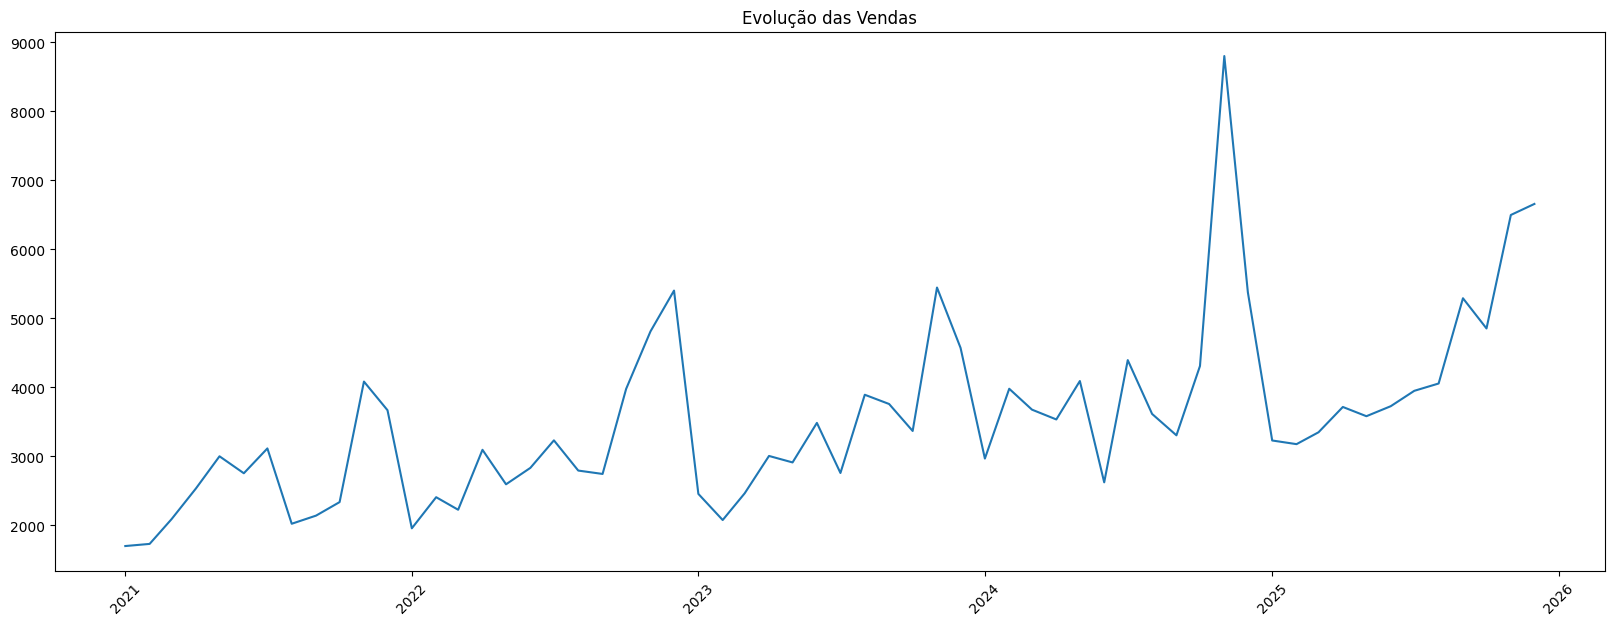

In [ ]:
# Série temporal - Evolução das Vendas
plt.figure(figsize=(20, 7))
plt.plot(dados["data"], dados["vendas"])
plt.title("Evolução das Vendas")
plt.xticks(rotation=45)
plt.show()

### Evolução das Vendas ao Longo do Tempo

Este gráfico de linha mostra o comportamento das vendas mês a mês, ao longo dos anos. Ele nos ajuda a identificar tendências gerais, como crescimento ou declínio, e a observar ciclos de longo prazo. Podemos ver claramente os altos e baixos das vendas, revelando a pulsação do negócio.

**Interpretação para leigos:**

Observe a linha azul: ela geralmente sobe ao longo do tempo, o que é um excelente sinal de crescimento contínuo do negócio. No entanto, você também pode notar picos e vales que se repetem anualmente, indicando a sazonalidade, que exploraremos em mais detalhes nos próximos gráficos. Essa visão geral mostra que a empresa está expandindo suas vendas a cada ano, apesar das flutuações mensais.

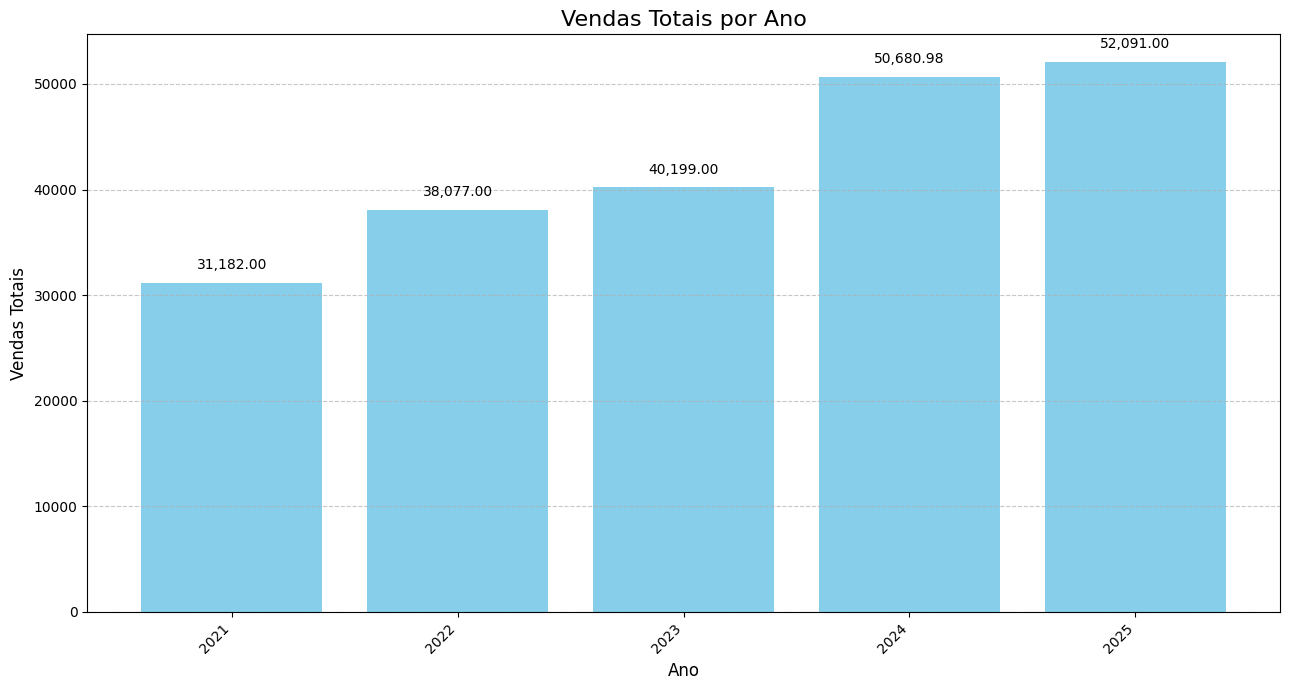

In [ ]:
# Série temporal - Vendas por Ano
plt.figure(figsize=(13, 7))
plt.bar(resumo_anual.index.astype(str), resumo_anual['vendas_total'], color='skyblue')
plt.title('Vendas Totais por Ano', fontsize=16)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Vendas Totais', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionar rótulos de valores nas barras para maior destaque
for index, value in enumerate(resumo_anual['vendas_total']):
    plt.text(index, value + 1000, f'{value:,.2f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### Vendas Totais por Ano

Este gráfico de barras apresenta o total de vendas para cada ano. Ele oferece uma visão clara do crescimento anual do negócio, permitindo comparar o desempenho de um ano para outro. Cada barra representa a soma de todas as vendas realizadas naquele ano específico.

**Interpretação para leigos:**

As barras mostram que as vendas totais têm aumentado consistentemente a cada ano, de 2021 a 2025. Isso confirma a tendência de crescimento que vimos no gráfico de linha anterior e é um indicador muito positivo da saúde do negócio. O ano de 2024 e 2025, em particular, mostram saltos significativos nas vendas, evidenciando uma expansão robusta.

### Sazonalidade

A sazonalidade refere-se a padrões previsíveis que se repetem em intervalos regulares, como mensalmente, trimestralmente ou anualmente. No e-commerce, a identificação da sazonalidade nas vendas é crucial para otimizar estoques, planejar campanhas de marketing e alocar recursos de forma eficiente, aproveitando os picos de demanda e mitigando as quedas.

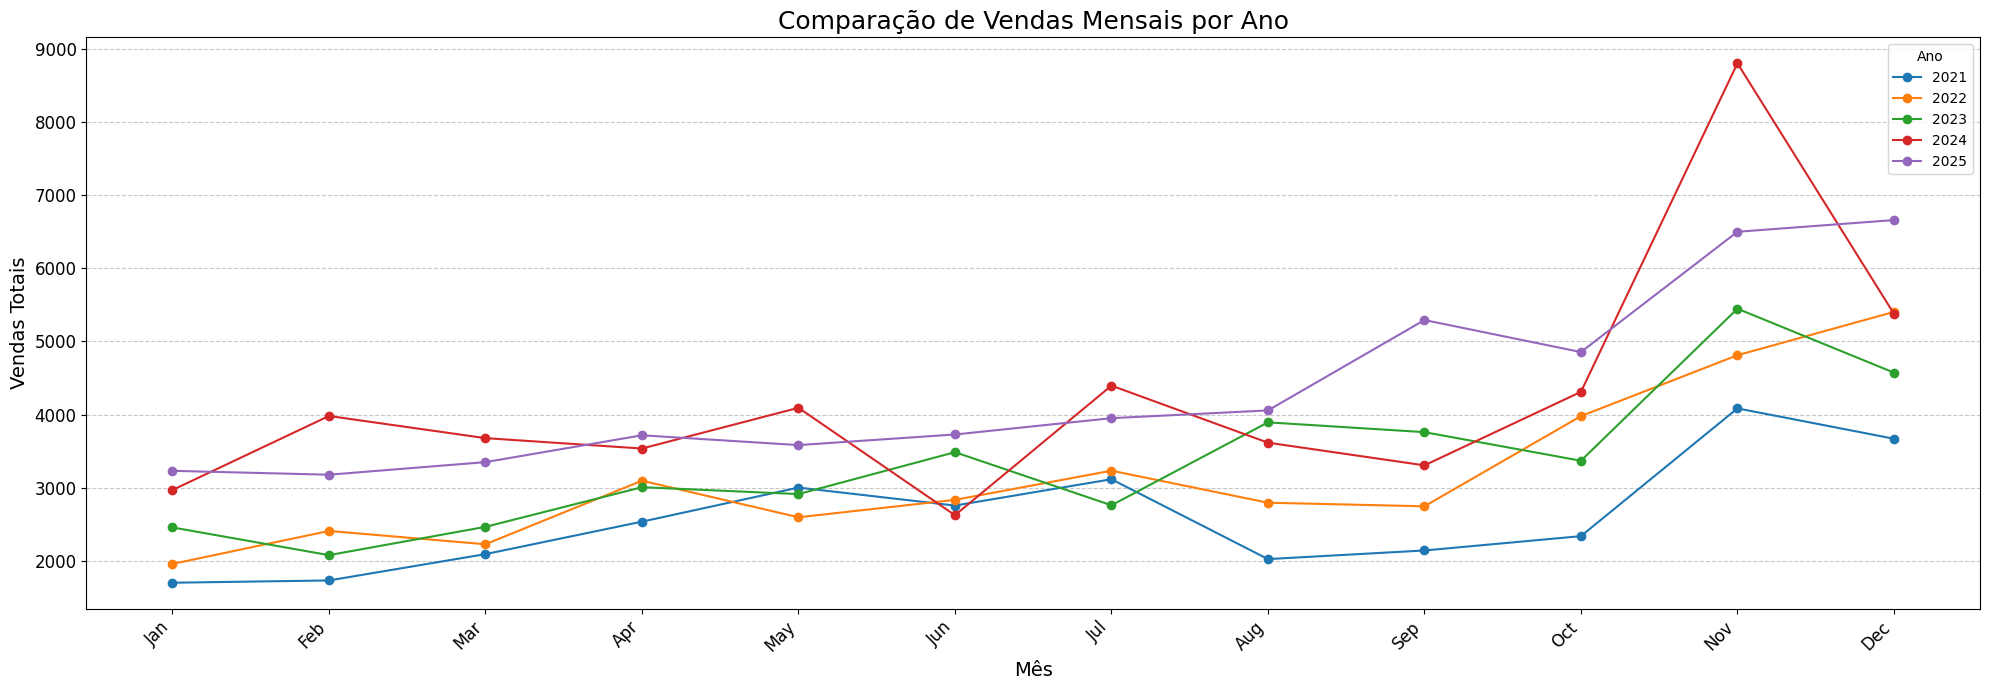

In [ ]:
# Sazonalidade - Historiograma anual

# Obter os anos únicos presentes nos dados
unique_years = sorted(dados['ano'].unique())

# Criar figura única
plt.figure(figsize=(20, 7))

# Loop pelos anos
for year in unique_years:
    # Filtrar os dados para o ano atual
    df_year = dados[dados['ano'] == year]

    # Agrupar por mês e somar as vendas
    sales_by_month = df_year.groupby(['mes', 'nome_mes'])['vendas'].sum().reset_index()

    # Ordenar corretamente os meses
    sales_by_month = sales_by_month.sort_values(by='mes')

    # Plotar linha para cada ano
    plt.plot(
        sales_by_month['nome_mes'],
        sales_by_month['vendas'],
        marker='o',
        linestyle='-',
        label=str(year)
    )

plt.title('Comparação de Vendas Mensais por Ano', fontsize=18)
plt.xlabel('Mês', fontsize=14)
plt.ylabel('Vendas Totais', fontsize=14)

plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Legenda
plt.legend(title='Ano')

plt.tight_layout()
plt.show()

### Comparação de Vendas Mensais por Ano (Sazonalidade)

Este gráfico de linha compara as vendas mensais para cada ano, permitindo identificar padrões sazonais que se repetem. Cada linha colorida representa um ano diferente, e podemos ver como as vendas se comportam em janeiro, fevereiro, março, e assim por diante, para cada um desses anos. É uma ferramenta poderosa para entender os meses de pico e os meses de baixa.

**Interpretação para leigos:**

Note que todas as linhas (representando os anos) tendem a seguir um padrão similar. Por exemplo, geralmente há uma queda nas vendas no início do ano (Janeiro/Fevereiro) e um aumento significativo nos últimos meses (Novembro/Dezembro), o que é comum no varejo, especialmente com eventos como a Black Friday e o Natal. Cada ano parece ter seus próprios picos e vales, mas o formato geral da curva mensal é consistente. Isso ajuda a planejar estoques e campanhas de marketing para aproveitar os meses de alta e minimizar os impactos dos meses de baixa.

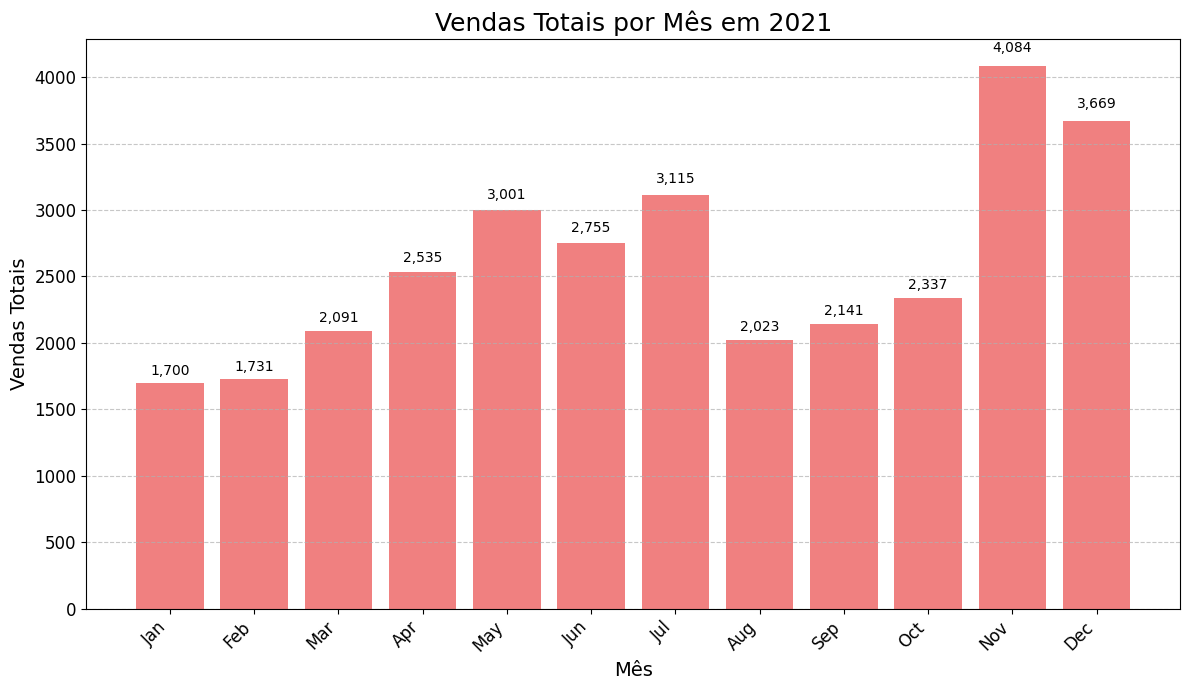

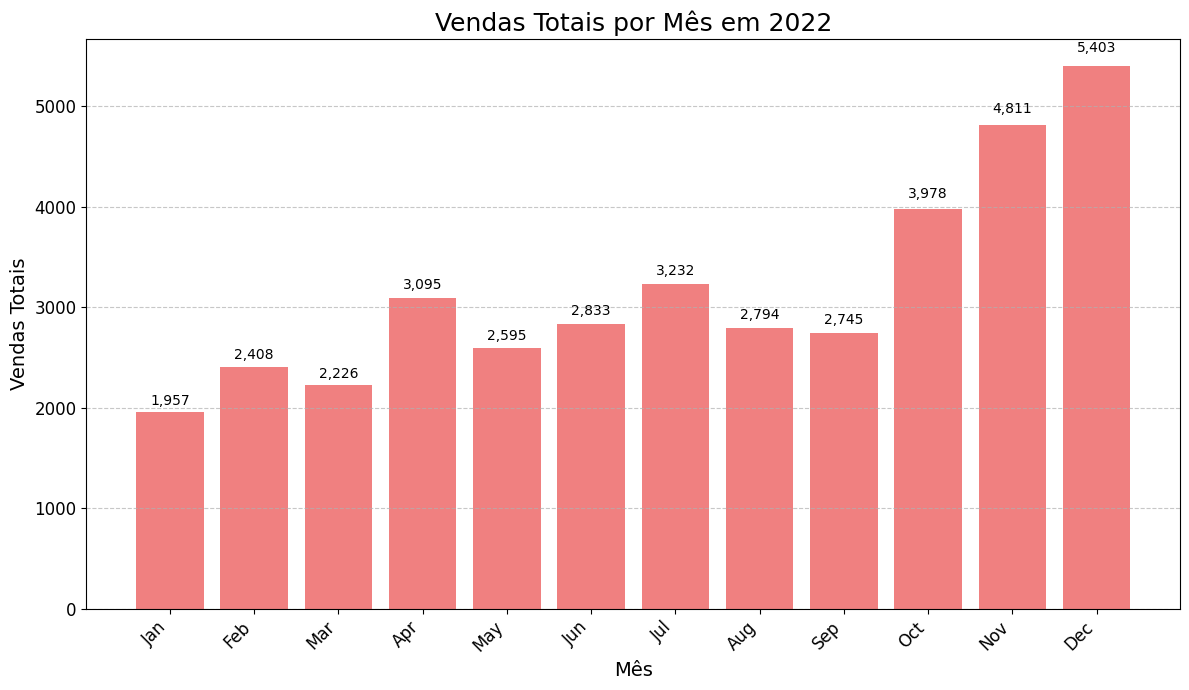

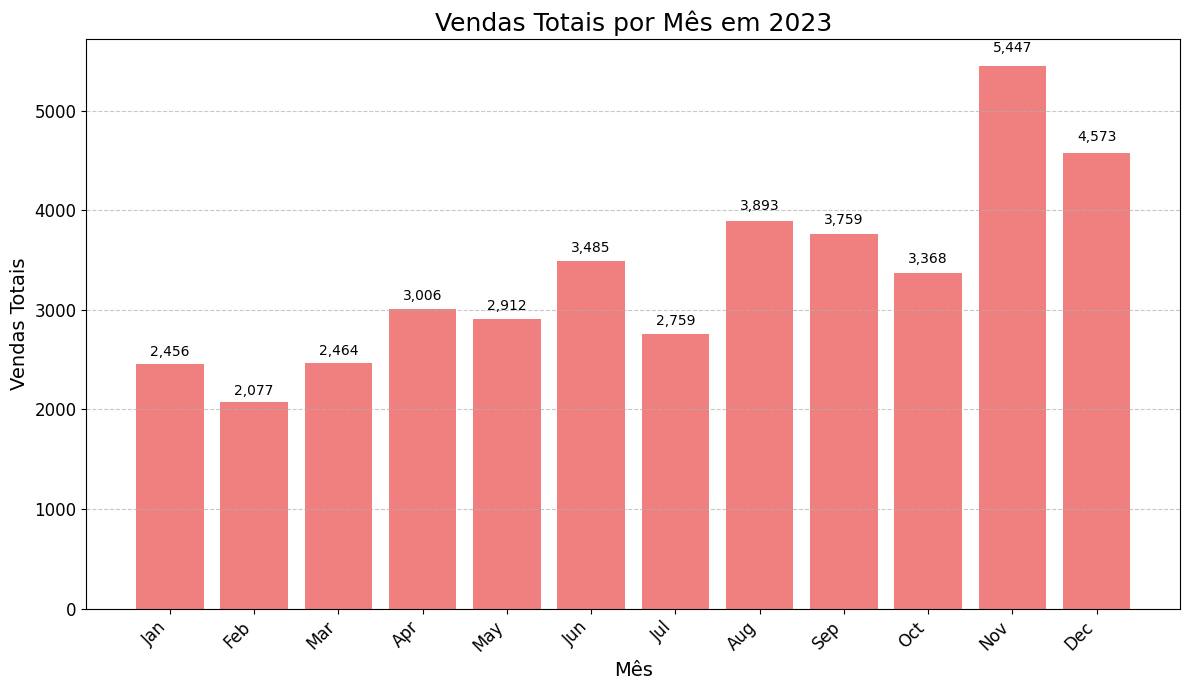

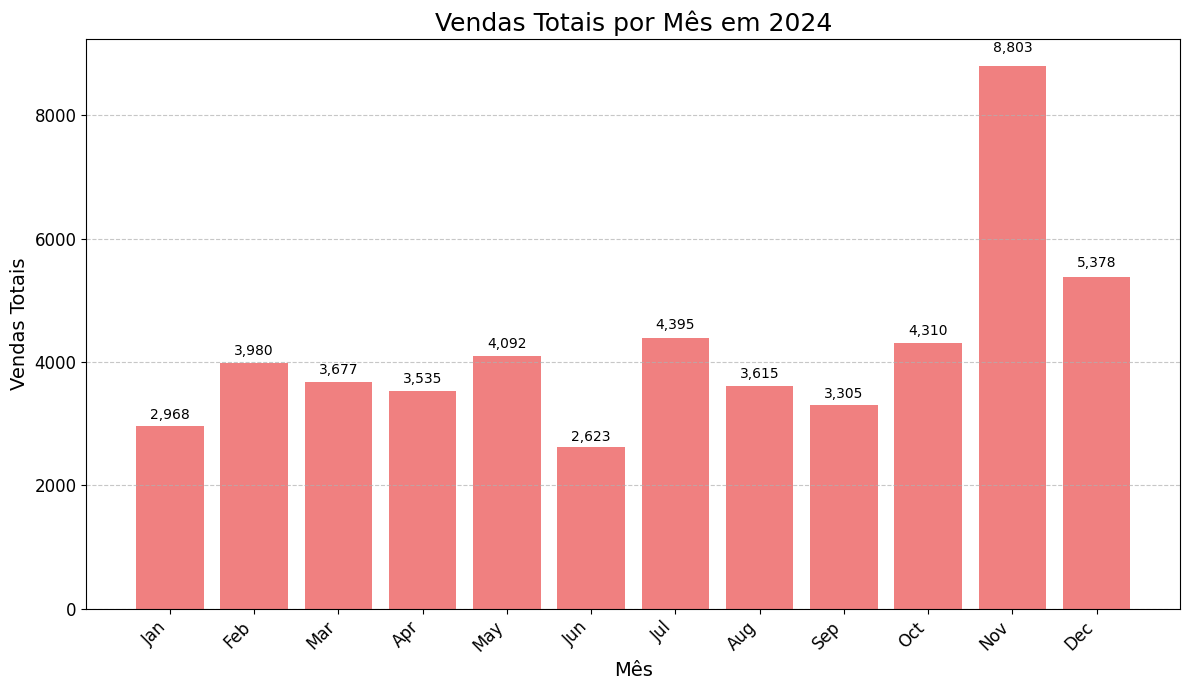

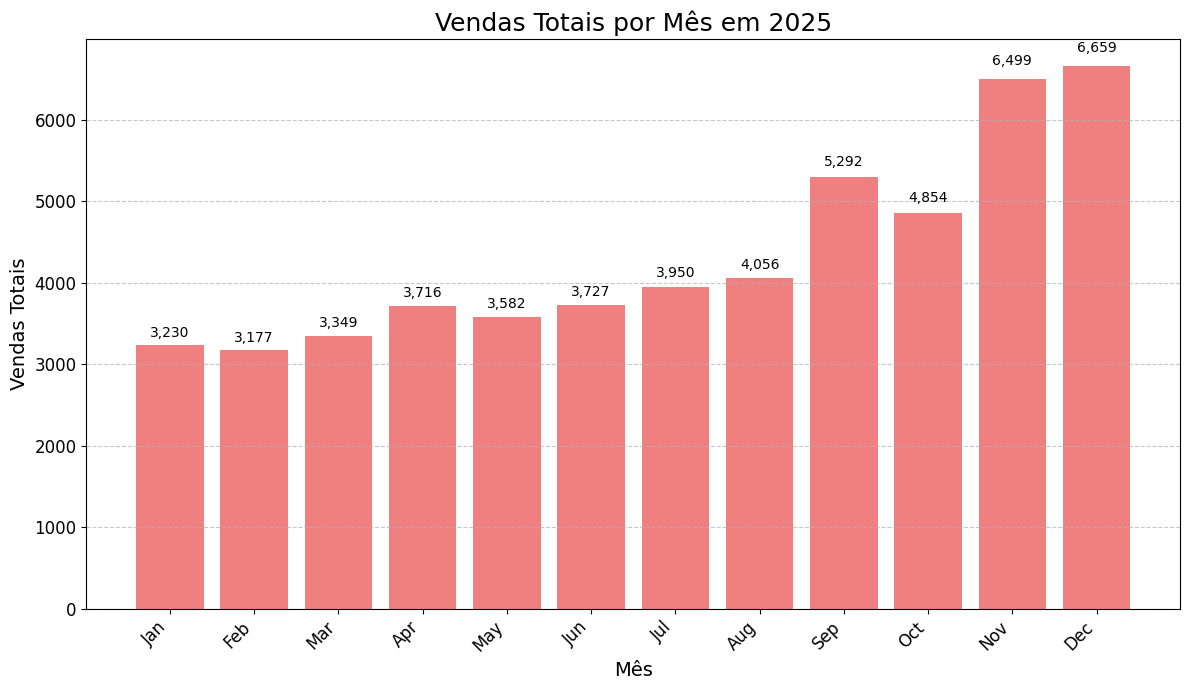

In [ ]:
# Sazonalidade - Historiograma Mensal

# Obter os anos únicos presentes nos dados
unique_years = sorted(dados['ano'].unique())

for year in unique_years:
    # Filtrar os dados para o ano atual
    df_year = dados[dados['ano'] == year]

    # Agrupar por mês e somar as vendas
    sales_by_month = df_year.groupby(['mes', 'nome_mes'])['vendas'].sum().reset_index()

    # Garantir a ordenação correta dos meses no gráfico
    sales_by_month = sales_by_month.sort_values(by='mes')

    # Criar o gráfico de barras para o ano atual
    plt.figure(figsize=(12, 7))
    plt.bar(sales_by_month['nome_mes'], sales_by_month['vendas'], color='lightcoral')
    plt.title(f'Vendas Totais por Mês em {year}', fontsize=18)
    plt.xlabel('Mês', fontsize=14)
    plt.ylabel('Vendas Totais', fontsize=14)
    plt.xticks(rotation=45, ha='right', fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Adicionar rótulos de valores nas barras para maior destaque
    for index, value in enumerate(sales_by_month['vendas']):
        plt.text(index, value + 0.02 * value, f'{value:,.0f}', ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.show()

### Vendas Totais por Mês em Cada Ano

Esses gráficos de barras individuais para cada ano detalham as vendas mês a mês, oferecendo uma visão mais granular da sazonalidade. Cada gráfico se concentra em um único ano, mostrando a contribuição de cada mês para o total anual de vendas. Isso complementa o gráfico de comparação anual, permitindo uma análise aprofundada de um ano específico.

**Interpretação para leigos:**

Ao observar os gráficos de barras para cada ano, você pode ver claramente quais meses foram os mais fortes e os mais fracos. Por exemplo, em todos os anos, os meses de Novembro e Dezembro se destacam com as maiores vendas, enquanto Janeiro e Fevereiro geralmente apresentam vendas mais baixas. Esta repetição de padrões mês a mês, ano após ano, é a essência da sazonalidade. Conhecer esses padrões ajuda a empresa a se preparar melhor, seja aumentando o estoque antes dos picos ou planejando promoções durante os meses mais lentos.

### Marketing e Vendas

A relação entre marketing e vendas é um pilar para o crescimento de qualquer negócio. Nesta seção, exploramos como o investimento em marketing impacta diretamente o volume de vendas. Analisamos a correlação entre essas variáveis e calculamos o Retorno sobre o Investimento (ROI) de Marketing para avaliar a eficácia das campanhas e guiar decisões futuras de alocação de verbas.

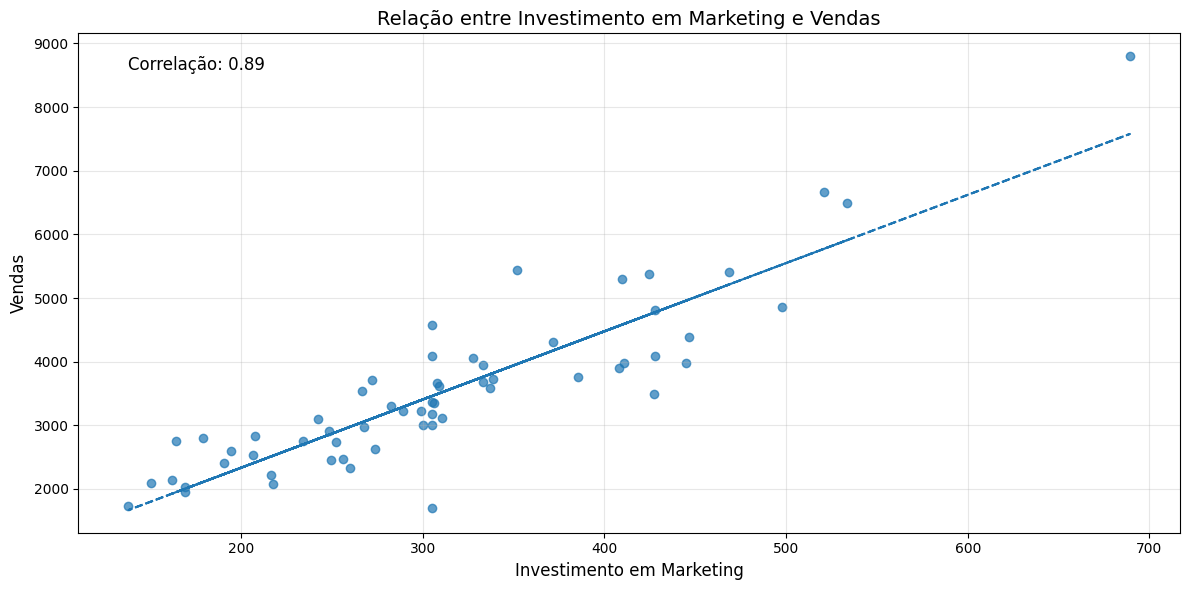

In [ ]:
# Marketing e vendas
plt.figure(figsize=(12, 6))
plt.scatter(
    dados["investimento_marketing"],
    dados["vendas"],
    alpha=0.7
)

# LINHA DE TENDÊNCIA (regressão linear)

# Ajustar uma linha (y = ax + b)
coef = np.polyfit(dados["investimento_marketing"], dados["vendas"], 1)
linha_tendencia = np.poly1d(coef)

# Plotar linha
plt.plot(
    dados["investimento_marketing"],
    linha_tendencia(dados["investimento_marketing"]),
    linestyle='--'
)

plt.title("Relação entre Investimento em Marketing e Vendas", fontsize=14)
plt.xlabel("Investimento em Marketing", fontsize=12)
plt.ylabel("Vendas", fontsize=12)

plt.grid(alpha=0.3)

correlacao = dados["investimento_marketing"].corr(dados["vendas"])

plt.text(
    dados["investimento_marketing"].min(),
    dados["vendas"].max(),
    f"Correlação: {correlacao:.2f}",
    fontsize=12,
    verticalalignment='top'
)

plt.tight_layout()
plt.show()

### Relação entre Investimento em Marketing e Vendas

Este gráfico de dispersão mostra a relação direta entre o quanto é investido em marketing e o volume de vendas gerado. Cada ponto no gráfico representa um mês, com o investimento em marketing no eixo horizontal e as vendas no eixo vertical. A linha tracejada vermelha é uma "linha de tendência", que nos mostra a direção geral dessa relação.

**Interpretação para leigos:**

Você pode observar que os pontos no gráfico tendem a subir da esquerda para a direita, e a linha de tendência acompanha essa ascensão. Isso significa que, em geral, quanto maior o investimento em marketing (os pontos mais à direita), maiores são as vendas (os pontos mais acima). A correlação de 0.89, que é bastante alta, confirma que há uma forte ligação positiva entre marketing e vendas: investir mais em marketing tende a resultar em mais vendas. Isso sugere que o marketing é um motor crucial para o crescimento do negócio.

### Cálculo do ROI de Marketing Anual

Vamos calcular o Retorno sobre o Investimento (ROI) de Marketing anualmente para entender a eficácia dos gastos em marketing em relação às vendas geradas. A fórmula utilizada será:

`ROI = ((Vendas Totais - Investimento em Marketing) / Investimento em Marketing) * 100`

In [ ]:
marketing_roi = dados.groupby('ano').agg(
    vendas_total=('vendas', 'sum'),
    marketing_total=('investimento_marketing', 'sum')
).reset_index()

marketing_roi['roi_marketing_%'] = ((marketing_roi['vendas_total'] - marketing_roi['marketing_total']) / marketing_roi['marketing_total']) * 100

print("ROI de Marketing Anual:")
display(marketing_roi[['ano', 'vendas_total', 'marketing_total', 'roi_marketing_%']])

ROI de Marketing Anual:


,ano,vendas_total,marketing_total,roi_marketing_%
0,2021,31182.00,2976.29,947.680166
1,2022,38077.00,3292.19,1056.585738
2,2023,40199.00,3618.57,1010.908453
3,2024,50680.98,4380.25,1057.033959
4,2025,52091.00,4470.55,1065.203387


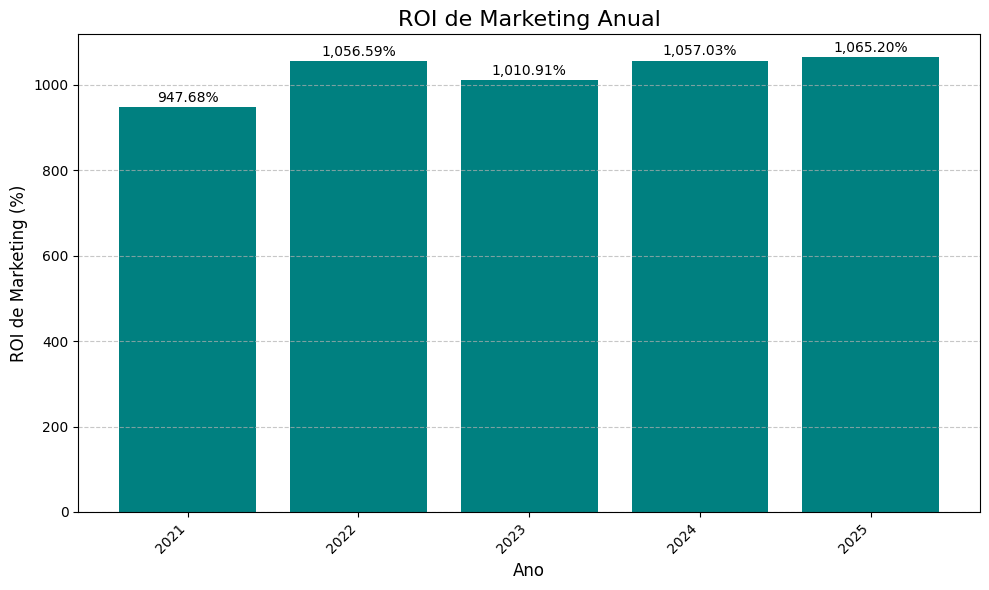

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(marketing_roi['ano'].astype(str), marketing_roi['roi_marketing_%'], color='teal')
plt.title('ROI de Marketing Anual', fontsize=16)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('ROI de Marketing (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for index, value in enumerate(marketing_roi['roi_marketing_%']):
    plt.text(index, value + 5, f'{value:,.2f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### ROI de Marketing Anual

Este gráfico de barras exibe o Retorno sobre o Investimento (ROI) de Marketing para cada ano. O ROI nos diz o quanto de lucro (ou vendas neste caso) foi gerado para cada unidade de dinheiro investida em marketing. Um ROI positivo e alto é um bom sinal, indicando que o investimento em marketing está sendo eficaz.

**Interpretação para leigos:**

Cada barra mostra o percentual de retorno do investimento em marketing para um determinado ano. Por exemplo, um ROI de 947.68% em 2021 significa que para cada R$1,00 investido em marketing, a empresa obteve R$9,47 em vendas (após cobrir o custo do marketing). Vemos que o ROI de marketing tem se mantido em níveis muito elevados e consistentes ao longo dos anos (todos acima de 900%), o que é excelente. Isso indica que as campanhas de marketing estão gerando um retorno muito significativo, tornando-as um investimento altamente lucrativo para o negócio.

### Teste de Elasticidade de Preço

A elasticidade de preço da demanda (EPD) é uma medida que indica o quanto a quantidade demandada de um bem ou serviço responde a uma alteração no seu preço. É calculada pela fórmula:

`EPD = (% Variação na Quantidade Demandada) / (% Variação no Preço)`

- Se EPD > 1: A demanda é considerada elástica (grandes mudanças na demanda para pequenas mudanças no preço).
- Se EPD < 1: A demanda é considerada inelástica (pequenas mudanças na demanda para grandes mudanças no preço).
- Se EPD = 1: A demanda é de elasticidade unitária.

Vamos calcular a elasticidade de preço mensal usando as colunas `vendas` e `preco_medio`.

In [ ]:
# Ordenar os dados por data para garantir a sequência correta
dados_sorted = dados.sort_values(by='data').copy()

# Calcular a variação percentual das vendas e do preço médio
dados_sorted['pct_change_vendas'] = dados_sorted['vendas'].pct_change() * 100
dados_sorted['pct_change_preco'] = dados_sorted['preco_medio'].pct_change() * 100

# Calcular a Elasticidade de Preço (EPD)
# Para evitar divisão por zero, substituímos 0 por NaN na variação de preço
# e depois removemos as linhas com NaN na EPD
dados_sorted['elasticidade_preco'] = dados_sorted.apply(
    lambda row: row['pct_change_vendas'] / row['pct_change_preco'] if row['pct_change_preco'] != 0 else np.nan,
    axis=1
)

# Exibir os resultados relevantes
elasticidade_df = dados_sorted[['data', 'vendas', 'preco_medio', 'pct_change_vendas', 'pct_change_preco', 'elasticidade_preco']].dropna(subset=['elasticidade_preco'])

print("Elasticidade de Preço Mensal:")
display(elasticidade_df.head())


Elasticidade de Preço Mensal:


,data,vendas,preco_medio,pct_change_vendas,pct_change_preco,elasticidade_preco
1,2021-02-01,1731.0,113.59,1.823529,1.929289,0.945182
2,2021-03-01,2091.0,118.96,20.797227,4.727529,4.399175
3,2021-04-01,2535.0,113.15,21.233859,-4.883995,-4.347642
4,2021-05-01,3001.0,103.62,18.382643,-8.422448,-2.182577
5,2021-06-01,2755.0,102.64,-8.197268,-0.945763,8.667356


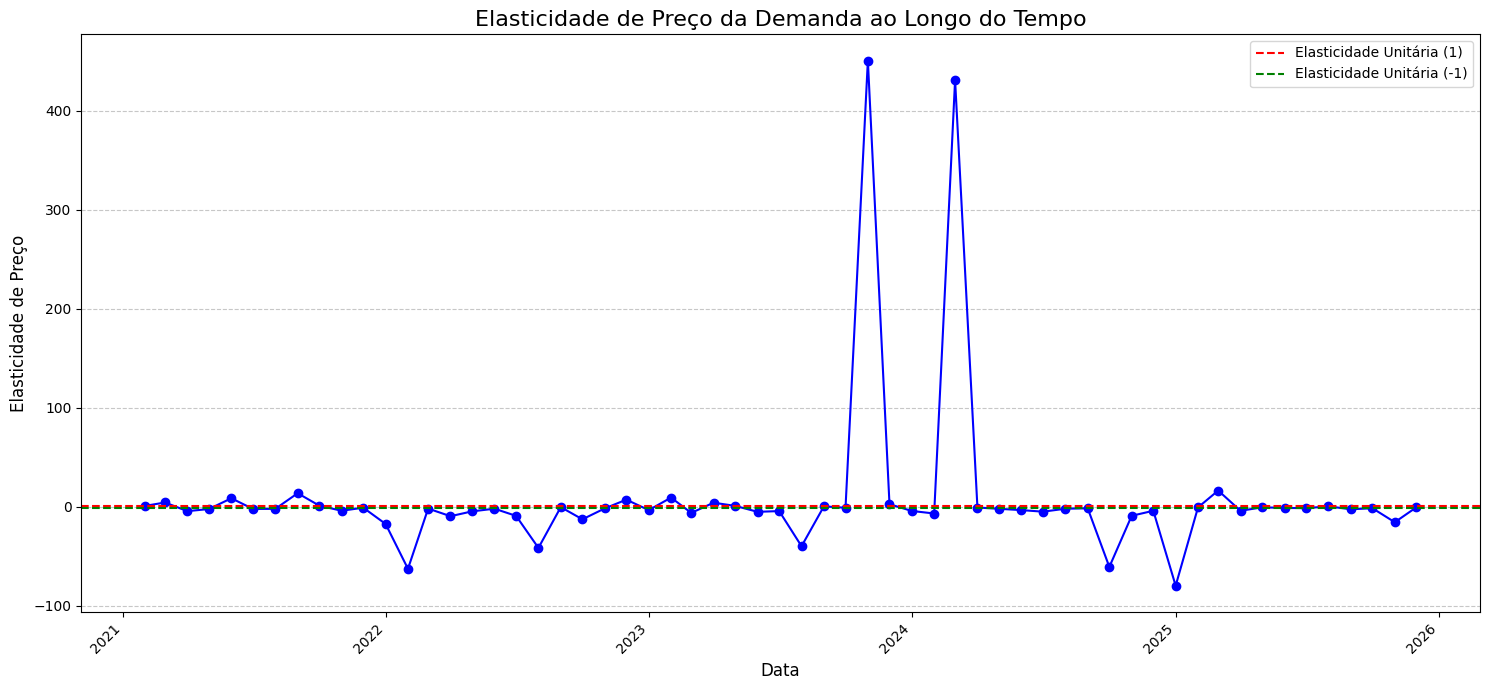

In [ ]:
# Visualização da Elasticidade de Preço ao longo do tempo
plt.figure(figsize=(15, 7))
plt.plot(elasticidade_df['data'], elasticidade_df['elasticidade_preco'], marker='o', linestyle='-', color='blue')
plt.axhline(1, color='red', linestyle='--', label='Elasticidade Unitária (1)')
plt.axhline(-1, color='green', linestyle='--', label='Elasticidade Unitária (-1)')

plt.title('Elasticidade de Preço da Demanda ao Longo do Tempo', fontsize=16)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Elasticidade de Preço', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()


### Elasticidade de Preço da Demanda ao Longo do Tempo

Este gráfico de linha mostra como a elasticidade de preço da demanda (EPD) variou ao longo do tempo. A EPD mede o quanto a quantidade de vendas reage a uma mudança no preço. As linhas tracejadas horizontais representam a elasticidade unitária (1 e -1), que é o ponto onde a mudança percentual nas vendas é igual à mudança percentual no preço.

**Interpretação para leigos:**

*   **Valores acima de 1 ou abaixo de -1 (demanda elástica):** Se a linha azul estiver acima da linha vermelha (1) ou abaixo da linha verde (-1), significa que a demanda é *elástica*. Pequenas mudanças no preço geram grandes mudanças nas vendas. Nesses períodos, baixar o preço pode aumentar muito as vendas, e subir o preço pode diminuir muito as vendas.
*   **Valores entre -1 e 1 (demanda inelástica):** Se a linha azul estiver entre as linhas tracejadas, a demanda é *inelástica*. Grandes mudanças no preço causam apenas pequenas mudanças nas vendas. Nesses períodos, a empresa tem mais flexibilidade para ajustar os preços sem perder muitas vendas (se aumentar) ou ganhar muitas vendas (se diminuir).

Ao longo do tempo, a elasticidade pode variar. Observar esse gráfico ajuda a empresa a entender os melhores momentos para ajustar os preços e prever o impacto dessas mudanças nas vendas.

## Modelagem Preditiva

A modelagem preditiva é uma técnica utilizada para prever resultados futuros com base em dados históricos. No contexto de vendas, ela nos permite entender quais fatores influenciam o volume de vendas e, assim, antecipar demandas futuras, otimizar estratégias e recursos. Vamos construir um modelo de regressão linear para prever as vendas com base em variáveis como promoção, investimento em marketing e preço médio.

Tamanho do conjunto de treino: 48 amostras
Tamanho do conjunto de teste: 12 amostras

Modelo de Regressão Linear treinado com sucesso!
Coeficiente (promocao): -826.10
Coeficiente (investimento_marketing): 12.18
Coeficiente (preco_medio): -25.29
Intercepto: 2903.35

Métricas de Avaliação do Modelo:
MAE (Erro Absoluto Médio): 423.27
MSE (Erro Quadrático Médio): 501917.53
RMSE (Raiz do Erro Quadrático Médio): 708.46
R-squared: 0.84


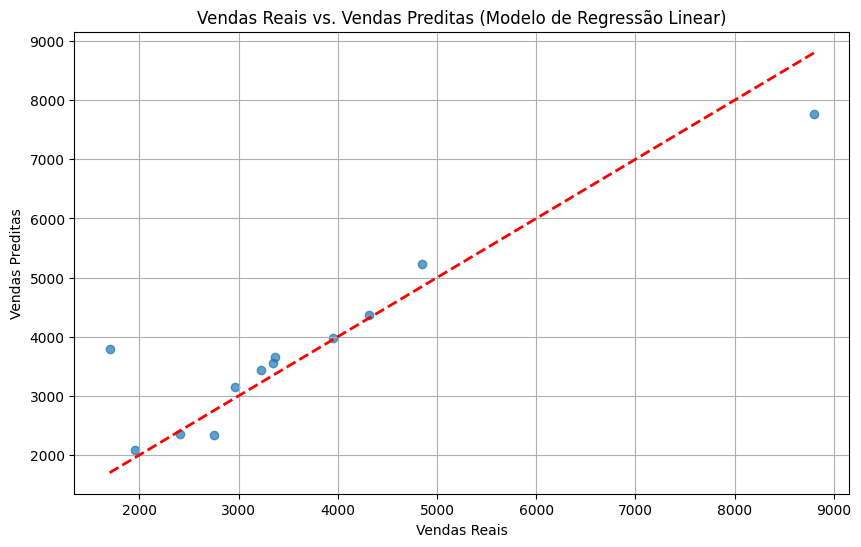

In [ ]:
# Seleção de features (variáveis independentes) e target (variável dependente)
X = dados[['promocao', 'investimento_marketing', 'preco_medio']]
y = dados['vendas']

# Divisão dos dados em treino e teste (80% treino, 20% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Tamanho do conjunto de treino: {len(X_train)} amostras")
print(f"Tamanho do conjunto de teste: {len(X_test)} amostras")

# Treinamento do Modelo de Regressão Linear
model = LinearRegression()
model.fit(X_train, y_train)

print("\nModelo de Regressão Linear treinado com sucesso!")
print(f"Coeficiente (promocao): {model.coef_[0]:.2f}")
print(f"Coeficiente (investimento_marketing): {model.coef_[1]:.2f}")
print(f"Coeficiente (preco_medio): {model.coef_[2]:.2f}")
print(f"Intercepto: {model.intercept_:.2f}")

# Avaliação do Modelo
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nMétricas de Avaliação do Modelo:")
print(f"MAE (Erro Absoluto Médio): {mae:.2f}")
print(f"MSE (Erro Quadrático Médio): {mse:.2f}")
print(f"RMSE (Raiz do Erro Quadrático Médio): {rmse:.2f}")
print(f"R-squared: {r2:.2f}")

# Visualização das Previsões vs. Valores Reais
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Vendas Reais')
plt.ylabel('Vendas Preditas')
plt.title('Vendas Reais vs. Vendas Preditas (Modelo de Regressão Linear)')
plt.grid(True)
plt.show()

### Vendas Reais vs. Vendas Preditas (Modelo de Regressão Linear)

Este gráfico de dispersão compara as vendas que realmente aconteceram (Vendas Reais) com as vendas que o nosso modelo de previsão estimou (Vendas Preditas). Cada ponto no gráfico representa uma observação. A linha tracejada vermelha mostra o que seria uma previsão perfeita: se o modelo fosse 100% preciso, todos os pontos estariam exatamente sobre essa linha.

**Interpretação para leigos:**

*   **Pontos próximos à linha vermelha:** Quanto mais próximos os pontos azuis estiverem da linha vermelha, melhor o nosso modelo está prevendo as vendas. Isso significa que as previsões estão muito próximas dos valores reais.
*   **Dispersão dos pontos:** Se os pontos estivessem muito espalhados ou longe da linha, significaria que o modelo não é muito bom para fazer previsões.

Neste gráfico, podemos ver que os pontos estão razoavelmente próximos à linha, indicando que o modelo de regressão linear está fazendo um bom trabalho na previsão das vendas, embora não seja perfeito (o que é normal em modelos preditivos). O R-squared de 0.84, que vimos anteriormente, confirma essa boa performance, significando que o modelo explica 84% da variação nas vendas.

## Conclusão Final

Este projeto realizou uma análise abrangente dos dados de vendas, explorando tendências, sazonalidade, o impacto de variáveis chave e a criação de um modelo preditivo. Os principais insights e respostas às questões de negócio são apresentados abaixo:

### Sumário dos Principais Achados:

1.  **Crescimento Consistente:** O negócio demonstrou um crescimento robusto e consistente ao longo dos anos, com as vendas totais aumentando anualmente.
2.  **Sazonalidade Marcante:** Há uma clara sazonalidade nas vendas, com picos notáveis nos meses de novembro e dezembro (impulsionados por eventos como Black Friday e Natal) e quedas nos primeiros meses do ano (janeiro e fevereiro). Este padrão se repete de forma previsível em todos os anos analisados.
3.  **Marketing como Grande Alavanca:** O investimento em marketing apresentou uma correlação muito forte e positiva com as vendas (0.89). Além disso, o Retorno sobre Investimento (ROI) de Marketing foi consistentemente elevado, superando 900% em todos os anos, indicando que cada real investido em marketing gera um retorno substancial em vendas.
4.  **Impacto de Promoções e Feriados:** Tanto as promoções quanto os feriados demonstraram ser impulsionadores significativos de vendas. As vendas médias em períodos promocionais e feriados foram consideravelmente superiores aos períodos sem esses fatores.
5.  **Sensibilidade ao Preço:** O preço médio mostrou uma correlação negativa com as vendas. O coeficiente no modelo preditivo confirmou que o aumento do preço médio tende a reduzir o volume de vendas. A análise de elasticidade de preço revelou que a demanda pode ser elástica em certos períodos, tornando as vendas muito sensíveis a mudanças de preço.
6.  **Modelo Preditivo Confiável:** O modelo de regressão linear desenvolvido atingiu um R-squared de 0.84, indicando que ele explica 84% da variação nas vendas. Os coeficientes do modelo destacaram o forte impacto positivo do investimento em marketing e o impacto negativo do preço médio nas vendas.

### Questões de Negócio e Respostas:

**1. Como podemos alavancar a sazonalidade para maximizar as vendas e mitigar as quedas?**

*   **Resposta:** É fundamental planejar campanhas de marketing intensivas e estratégias de estoque reforçado para os meses de pico (novembro e dezembro) para capitalizar a demanda. Nos meses de baixa (janeiro e fevereiro), a empresa deve considerar promoções estratégicas, ofertas exclusivas ou campanhas de fidelidade para estimular as vendas e suavizar a curva sazonal.

**2. Qual o impacto real do investimento em marketing e ele é justificado?**

*   **Resposta:** O investimento em marketing é um dos motores mais potentes para o crescimento das vendas, com uma forte correlação positiva e um ROI excepcional. O investimento é não apenas justificado, mas crucial. A empresa deveria considerar manter ou até mesmo otimizar e ampliar o orçamento de marketing, focando em campanhas que demonstraram maior eficácia, dado o retorno significativo que elas proporcionam.

**3. As promoções e feriados são estratégias eficazes para impulsionar o desempenho comercial?**

*   **Resposta:** Sim, as promoções e os feriados são comprovadamente eficazes. A média de vendas durante esses períodos é significativamente maior. A empresa deve continuar a desenvolver estratégias específicas para feriados e promoções, buscando otimizar o timing e o tipo de oferta para maximizar os resultados. A análise do impacto da promoção na Elasticidade de Preço pode refinar ainda mais essas estratégias.

**4. Como a precificação afeta as vendas e como podemos utilizá-la de forma mais estratégica?**

*   **Resposta:** O preço médio é um fator sensível para as vendas. Em períodos de demanda elástica (onde pequenas mudanças de preço geram grandes mudanças nas vendas), a empresa pode explorar reduções estratégicas de preço para impulsionar o volume. Em contrapartida, em períodos de demanda inelástica, pode haver margem para pequenos aumentos de preço sem perdas significativas de vendas. Acompanhar continuamente a elasticidade de preço é vital para decisões de precificação dinâmicas e otimizadas.

**5. Qual a confiabilidade do nosso modelo preditivo e como ele pode auxiliar na tomada de decisões?**

*   **Resposta:** O modelo de regressão linear demonstrou uma boa capacidade preditiva (R-squared de 0.84), o que o torna uma ferramenta confiável para projeções de vendas. Ele pode ser utilizado para simular cenários futuros, como o impacto estimado de um aumento no investimento em marketing ou de uma alteração no preço médio. Isso permite à gestão planejar alocações de recursos, metas de vendas e estratégias de marketing com maior confiança e base em dados.